In [2]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from anngeno import AnnGeno

/home/dnanexus/anngeno/anngeno/anngeno.py:14: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [3]:
# Configuration and paths
min_range = -0
max_range = +500

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)

config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Read the variant consequence configuration
records = []
for group, consequences in config["variant_consequences"].items():
    for consequence in consequences:
        records.append({'variant_class': group, 'vep_consequence': consequence})
var_cons = pl.DataFrame(records)


# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""plof""","""loftee_hc""","""#1f77b4""","""LOFTEE HC""",1
"""missense""","""am_pathogenicity""","""#e76e5b""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""conservation""","""gpn_star_llr_calibrated_mean""","""#942c80""","""GPN-Star""",-1
…,…,…,…,…
"""splicing""","""absplice_dna_max""","""#28a745""","""AbSplice (max)""",1
"""splicing""","""absplice2_max""","""#1E8449""","""AbSplice2 (max)""",1
"""regulatory_nondir""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",1


In [4]:
# Beltran et al. 2025
exp_df = pl.read_parquet("/home/dnanexus/data_dir/exp_data/250904_Beltran_447aPCA.parquet").rename({
    'dms_type': 'annotation',
    'dms_score': 'annotation_score'
})

exp_annos = ['fitness','FoldX','thermoMPNN']
exp_annos_df = pl.DataFrame({
    "category": ['aPCA', 'missense', 'missense'],
    'annotation': exp_annos,
    "color": ['gray', '#FF8800', '#FFBB88'],
    'label': ['aPCA fitness','FoldX','thermoMPNN'],
    'annotation_dir': [1, 1, 1],
})

anno_config_df = pl.concat([anno_config_df, exp_annos_df])

exp_df = exp_df.filter(
    pl.col('annotation').is_in(exp_annos)
).with_columns(
    pl.col('annotation_score').cast(pl.Float32),
).drop_nulls()

# [mutant, region] combinations where all of the exp_annos are present
valid_combos = (
    exp_df
    .group_by(["mutant", "region"])
    .agg(pl.col("annotation").n_unique().alias("n_annos"))
    .filter(pl.col("n_annos") == len(exp_annos))
    .select(["mutant", "region"])
)

# Join back if you want the filtered full dataset
exp_df = exp_df.join(valid_combos, on=["mutant", "region"])
exp_df

region,gene_name,mutant,annotation,annotation_score
str,str,str,str,f32
"""ENSG00000128610""","""FEZF1""","""A300C""","""fitness""",0.085555
"""ENSG00000128610""","""FEZF1""","""A300D""","""fitness""",0.092028
"""ENSG00000128610""","""FEZF1""","""A300E""","""fitness""",0.10999
"""ENSG00000128610""","""FEZF1""","""A300F""","""fitness""",0.064676
"""ENSG00000128610""","""FEZF1""","""A300G""","""fitness""",0.076879
…,…,…,…,…
"""ENSG00000186472""","""PCLO""","""W1104R""","""thermoMPNN""",1.99153
"""ENSG00000186472""","""PCLO""","""W1104S""","""thermoMPNN""",2.117514
"""ENSG00000186472""","""PCLO""","""W1104T""","""thermoMPNN""",1.988062


In [5]:
anno = pl.read_parquet("/home/dnanexus/data_dir/dms_coding.ag/annotations.parquet")
existing_annos = [c for c in all_annotation_list if c in anno.columns]

anno = anno.filter(
    pl.col('consequence_missense_variant') == 1
).select(
    set(['id', 'mutant', 'region']).union(set(existing_annos))
)

val_ids = anno[['mutant', 'id', 'region']].unique().join(exp_df[['mutant', 'region']].unique(), on=['mutant', 'region'], how='inner')
val_ids

mutant,id,region
str,str,str
"""A73S""","""chr3:186572243:G:T""","""ENSG00000090520"""
"""V1172L""","""chr2:24246192:C:G""","""ENSG00000198399"""
"""P439A""","""chr6:43187023:C:G""","""ENSG00000112659"""
"""K227T""","""chr5:149216969:A:C""","""ENSG00000173210"""
"""L167M""","""chr14:60509897:C:A""","""ENSG00000184302"""
…,…,…
"""E426A""","""chr8:38249736:A:C""","""ENSG00000085788"""
"""G1910A""","""chr9:13110736:C:G""","""ENSG00000107186"""
"""R905L""","""chr8:143804971:C:A""","""ENSG00000180900"""


In [6]:
melted_anno = anno.join(
    val_ids, 
    on=['mutant', 'id', 'region'], 
    how='inner'
).unpivot(
    index=["id", "mutant", "region"],
    on=existing_annos,
    variable_name="annotation",
    value_name="annotation_score"
).with_columns(
    pl.col("annotation_score").cast(pl.Float32),
    pl.col("region").cast(pl.Utf8),
).join(
    exp_df[['mutant', 'region']].unique(), 
    on=['mutant', 'region'], 
    how='inner'
)

exp_df_subset = exp_df.join(val_ids.unique(), on=['mutant', 'region'], how='inner')[melted_anno.columns]
melted_anno = pl.concat([melted_anno, exp_df_subset])

melted_anno

id,mutant,region,annotation,annotation_score
str,str,str,str,f32
"""chr9:130614315:G:T""","""C125F""","""ENSG00000107164""","""loftee_hc""",0.0
"""chr9:130614315:G:T""","""C125F""","""ENSG00000107164""","""am_pathogenicity""",0.9928
"""chr9:130614315:G:T""","""C125F""","""ENSG00000107164""","""esmscoremissense""",-10.356
"""chr9:130614315:G:T""","""C125F""","""ENSG00000107164""","""cadd_raw""",5.091384
"""chr9:130614315:G:T""","""C125F""","""ENSG00000107164""","""gpn_score""",-12.19
…,…,…,…,…
"""chr7:83134254:G:C""","""T1099S""","""ENSG00000186472""","""thermoMPNN""",-0.071114
"""chr7:83134293:A:T""","""V1086E""","""ENSG00000186472""","""thermoMPNN""",2.487643
"""chr7:83134294:C:T""","""V1086M""","""ENSG00000186472""","""thermoMPNN""",1.497053


In [7]:
# Get gene trait associations

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet")

gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner').filter(
    pl.col('loftee_corr')*pl.col('beta') > 0
).with_columns(
    corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
)
gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.014747,82603,-0.195409,9.1637e-8,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",-0.014338,13594,-0.397279,0.006626,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""",-0.010787,28541,-0.058463,0.000305,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.036259,20244,-0.436618,6.0395e-11,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.013644,82469,-0.412619,2.8609e-8,-1.0
…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""",0.033239,9849,0.952411,1.8038e-41,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",0.02685,54620,0.656849,2.1682e-10,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""",0.003971,55477,0.176348,2.1188e-7,1.0


In [8]:
appv = pl.read_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_dmsCoding_PRScorr.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique())

# Chain the filter and the much faster semi join
appv = appv.join(
    anno_keys, on='id', how='semi'
).filter(
    pl.col('n_individuals') <= mac
)

In [9]:
anno_flt = melted_anno.filter(
    pl.col('region').is_in(gene_trait_df['region'].unique())
).drop([c for c in anno.columns if 'is_nan' in c])

appv_flt = appv.filter(
    pl.col('id').is_in(anno_flt['id'].unique())
).drop('std_pheno_value').drop_nulls()

print(anno_flt.shape, appv_flt.shape)

/tmp/ipykernel_214740/2529300033.py:1: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_214740/2529300033.py:5: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


(3930, 5) (30681, 4)


In [ ]:
from scipy.stats import spearmanr

def calculate_spearman_corr(
    group_df: pl.DataFrame, col1: str, col2: str
) -> pl.DataFrame:
    n = len(group_df)
    keys = group_df.select(group_keys).head(1)
    
    if n < 2:
        corr, pval = None, None
    else:
        res = spearmanr(group_df[col1], group_df[col2])
        corr, pval = res.correlation, res.pvalue

    results = pl.DataFrame({
        "n_variants": [n],
        "corr_beta": [corr],
        "p_value": [pval]
    })

    return pl.concat([keys, results], how="horizontal")

# The list of columns you are grouping by
group_keys = ["region", "gene_name", "phenotype", "annotation", "label", "color"]

correlation_df = (
    appv_flt.lazy()
    .join(anno_flt.lazy(), on="id", how="inner")
    .join(gene_trait_df.lazy(), on=["region", "phenotype"], how="inner")
    .join(anno_config_df.lazy(), on='annotation', how='inner')
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col('annotation_dir'),
        mean_pheno_value_dircor = pl.col('mean_pheno_value') * pl.col('corr_dir'),
    )
    .group_by(group_keys)
    .map_groups(
        lambda df: calculate_spearman_corr(
            df, 
            col1="annotation_score_dircor", 
            col2="mean_pheno_value_dircor"
        ),
        schema={
            "region": pl.Utf8,
            "gene_name": pl.Utf8,
            "phenotype": pl.Utf8,
            "annotation": pl.Utf8,
            "label": pl.Utf8,
            "color": pl.Utf8,
            "n_variants": pl.Int64,
            "corr_beta": pl.Float64,
            "p_value": pl.Float64
        }
    )
    .collect(engine='streaming')
)

correlation_df

/tmp/ipykernel_214740/3695311356.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.


region,gene_name,phenotype,annotation,label,color,n_variants,corr_beta,p_value
str,str,str,str,str,str,i64,f64,f64
"""ENSG00000101191""","""DIDO1""","""hip_circumference_int""","""esmscoremissense""","""ESM1v""","""#feb72d""",16,0.029412,0.913896
"""ENSG00000163554""","""SPTA1""","""direct_bilirubin_int""","""FoldX""","""FoldX""","""#FF8800""",20,0.093233,0.695829
"""ENSG00000163554""","""SPTA1""","""mean_corpuscular_haemoglobin_i…","""am_pathogenicity""","""AlphaMissense""","""#e76e5b""",22,0.218521,0.328569
"""ENSG00000163554""","""SPTA1""","""reticulocyte_percentage_int""","""FoldX""","""FoldX""","""#FF8800""",22,-0.208357,0.352111
"""ENSG00000163554""","""SPTA1""","""high_light_scatter_reticulocyt…","""FoldX""","""FoldX""","""#FF8800""",22,-0.175607,0.434394
…,…,…,…,…,…,…,…,…
"""ENSG00000092148""","""HECTD1""","""standing_height_int""","""am_pathogenicity""","""AlphaMissense""","""#e76e5b""",26,0.259873,0.19981
"""ENSG00000163554""","""SPTA1""","""mean_corpuscular_haemoglobin_c…","""thermoMPNN""","""thermoMPNN""","""#FFBB88""",22,-0.180124,0.422475
"""ENSG00000029534""","""ANK1""","""reticulocyte_percentage_int""","""fitness""","""aPCA fitness""","""gray""",29,0.184729,0.337393


In [27]:
# Check if the variant counts are consistent within each (region, phenotype) pair
annos_w_inconsistent_assocs = (
    correlation_df
    .drop_nulls().drop_nans()
    .select(['region', 'gene_name', 'phenotype', 'annotation'])
    .group_by('annotation')
    .agg(n_associations = pl.len())
    .select('n_associations').n_unique()
) - 1

print(f"Annotations with inconsistent associations: {annos_w_inconsistent_assocs}")

# Check if the variant counts are consistent within each (region, phenotype) pair
var_inconsistent = (
    correlation_df
    .drop_nans()
    .drop_nulls()
    .group_by(["region", "phenotype"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

Annotations with inconsistent associations: 0
Inconsistent (region, phenotype) pairs: 0


In [28]:
from scipy.stats import t

df_with_pvalue = correlation_df.with_columns(
    p_value = pl.when(pl.col("corr_beta").abs() == 1.0)
    .then(0.0)
    .otherwise(
        # CORRECTED LINE: Call .map_elements() on the pl.struct expression
        pl.struct(["corr_beta", "n_variants"]).map_elements(
            lambda row: 2 * t.sf(
                abs(
                    row["corr_beta"] *
                    ((row["n_variants"] - 2) / (1 - row["corr_beta"]**2))**0.5
                ),
                df=(row["n_variants"] - 2)
            ),
            return_dtype=pl.Float64
        )
    )
)

df_with_pvalue.filter(pl.col('p_value') < 0.05)#.sort(pl.col('p_value')).head(10)

region,gene_name,phenotype,annotation,label,color,n_variants,corr_beta,p_value
str,str,str,str,str,str,i64,f64,f64
"""ENSG00000163554""","""SPTA1""","""mean_corpuscular_haemoglobin_i…","""FoldX""","""FoldX""","""#FF8800""",22,-0.428571,0.046584
"""ENSG00000136068""","""FLNB""","""gamma_glutamyltransferase_int""","""cadd_raw""","""CADD Raw""","""#1f77b4""",102,0.211528,0.032825
"""ENSG00000163554""","""SPTA1""","""mean_reticulocyte_volume_int""","""FoldX""","""FoldX""","""#FF8800""",22,0.473744,0.025933
"""ENSG00000163554""","""SPTA1""","""high_light_scatter_reticulocyt…","""fitness""","""aPCA fitness""","""gray""",22,-0.436477,0.042264
"""ENSG00000092148""","""HECTD1""","""standing_height_int""","""esmscoremissense""","""ESM1v""","""#feb72d""",26,0.484185,0.012196


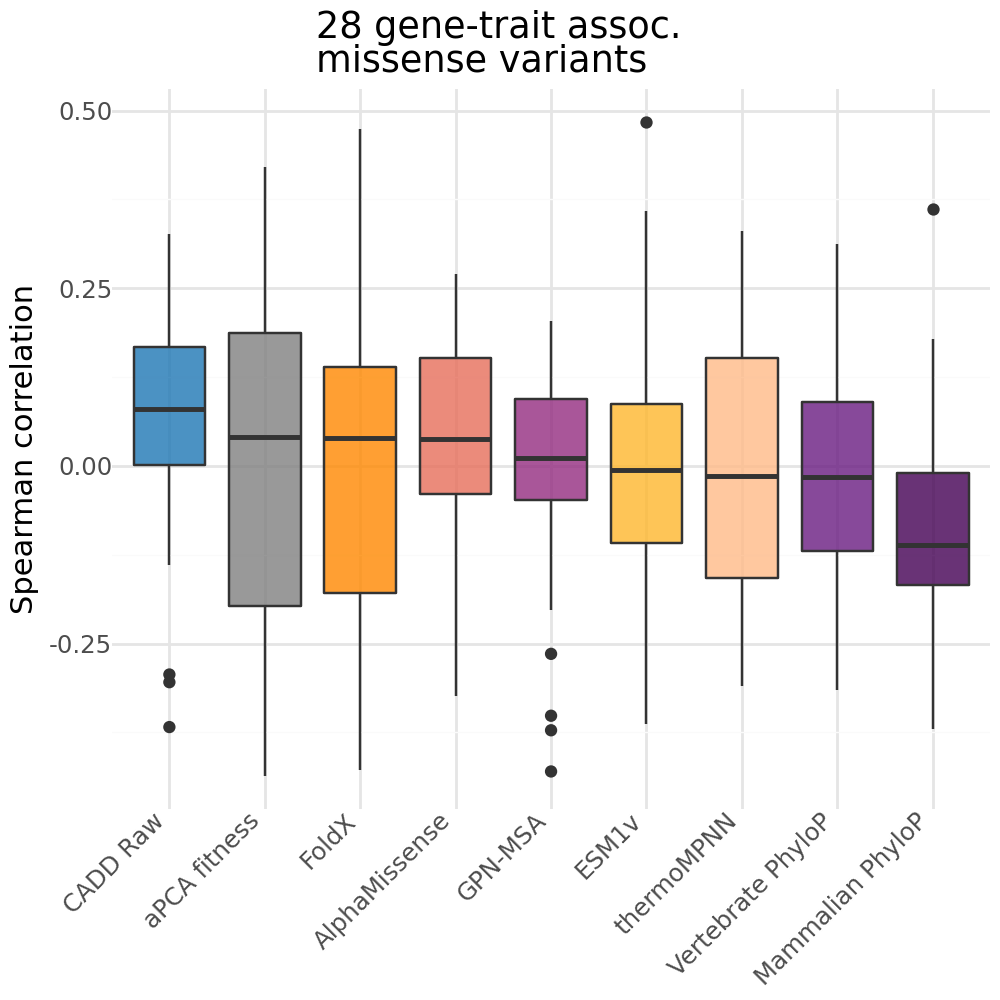

In [29]:
med_df = correlation_df.drop_nans().group_by("label").agg(
    median_corr_beta = pl.col("corr_beta").median(),
)

corr_pd = med_df.join(correlation_df, on='label').to_pandas()

corr_pd['label'] = pd.Categorical(
    corr_pd['label'],
    categories=corr_pd.sort_values('median_corr_beta', ascending=False)['label'].unique(),
    ordered=True
)

# Define colors
color_dict = dict(zip(corr_pd['annotation'], corr_pd['color']))

# Plot
(
    ggplot(corr_pd, aes(x='label', y='corr_beta', fill='annotation')) +
    geom_boxplot(alpha=0.8) +
    theme_minimal() +
    # scale_y_continuous(limits=[-0.5, 0.6]) +
    scale_fill_manual(values=color_dict) +
    labs(
        x='',
        y='Spearman correlation',
        title=f"{corr_pd[['region', 'phenotype']].drop_duplicates().shape[0]} gene-trait assoc. \
        \nmissense variants"
    ) +
    theme(
        figure_size=(5, 5),
        legend_position='none',
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

In [17]:
import itertools
from scipy.stats import wilcoxon

annotations = correlation_df.select(pl.col("annotation")).unique().to_series().to_list()
pairs = list(itertools.combinations(annotations, 2))

results = []
for a, b in pairs:
    # Subset to same gene-trait pairs where both VSMs have values
    df_a = correlation_df.filter(pl.col("annotation") == a).select(["region", "phenotype", "corr_beta"])
    df_b = correlation_df.filter(pl.col("annotation") == b).select(["region", "phenotype", "corr_beta"])

    merged = df_a.join(df_b, on=["region", "phenotype"], how="inner", suffix="_b")

    if merged.height > 0:
        stat, pval = wilcoxon(merged["corr_beta"].to_numpy(), merged["corr_beta_b"].to_numpy(), alternative="two-sided")
        results.append((a, b, merged.height, stat, pval))

# Make results dataframe
stats_df = pl.DataFrame(
    results,
    schema=["VSM_A", "VSM_B", "gene_trait_pairs", "W_stat", "pval_raw"]
)

stats_df.filter(pl.col("pval_raw") < 0.05)

/tmp/ipykernel_761493/2641523769.py:20: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.


VSM_A,VSM_B,gene_trait_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""mamphylop""","""esmscoremissense""",28,110.0,0.033681
"""mamphylop""","""verphylop""",28,112.0,0.03793
"""mamphylop""","""gpn_score""",28,115.0,0.045118
"""mamphylop""","""cadd_raw""",28,64.0,0.000966
"""mamphylop""","""am_pathogenicity""",28,81.0,0.004407
"""verphylop""","""cadd_raw""",28,114.0,0.042608
"""gpn_score""","""cadd_raw""",28,103.0,0.021779
"""gpn_score""","""am_pathogenicity""",28,109.0,0.031709


In [29]:
stats_df

VSM_A,VSM_B,gene_trait_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""FoldX""","""thermoMPNN""",28,198.0,0.919671
"""FoldX""","""mamphylop""",28,137.0,0.137518
"""FoldX""","""esmscoremissense""",28,191.0,0.796562
"""FoldX""","""loftee_hc""",28,NaN,NaN
"""FoldX""","""verphylop""",28,185.0,0.694702
…,…,…,…,…
"""gpn_score""","""am_pathogenicity""",28,109.0,0.031709
"""gpn_score""","""fitness""",28,176.0,0.551874
"""cadd_raw""","""am_pathogenicity""",28,188.0,0.980833


## Single gene trait associtaion plot

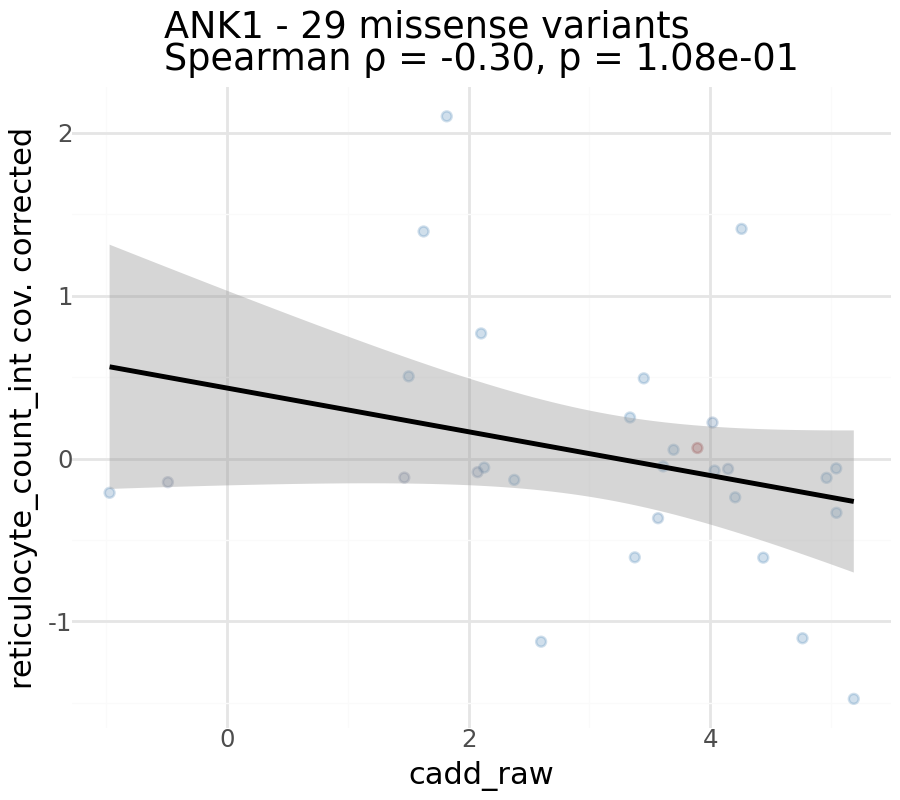

In [31]:
from scipy.stats import spearmanr

annotation = 'cadd_raw'
gene_name = "ANK1"
phenotype = "reticulocyte_count_int"

plot_df = pheno_anno.filter(
    (pl.col('phenotype') == phenotype) &
    (pl.col('gene_name') == gene_name) &
    (pl.col('annotation') == annotation)
)

spearman_corr, p_value = spearmanr(
        plot_df['annotation_score'],
        plot_df['mean_pheno_value']
    )

(
    ggplot(plot_df, aes(x='annotation_score', y='mean_pheno_value', color='n_individuals')) +
    geom_point(alpha=0.25) +
    stat_smooth(method='glm', se=True) +
    scale_color_gradient(low='steelblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{annotation}",
        y=f"{phenotype} cov. corrected",
        title=f"{gene_name} - {plot_df.shape[0]} missense variants\nSpearman ρ = {spearman_corr:.2f}, p = {p_value:.2e}"
    ) +
    theme(
        figure_size=(4.5, 4),
        legend_position='none'
    )
)

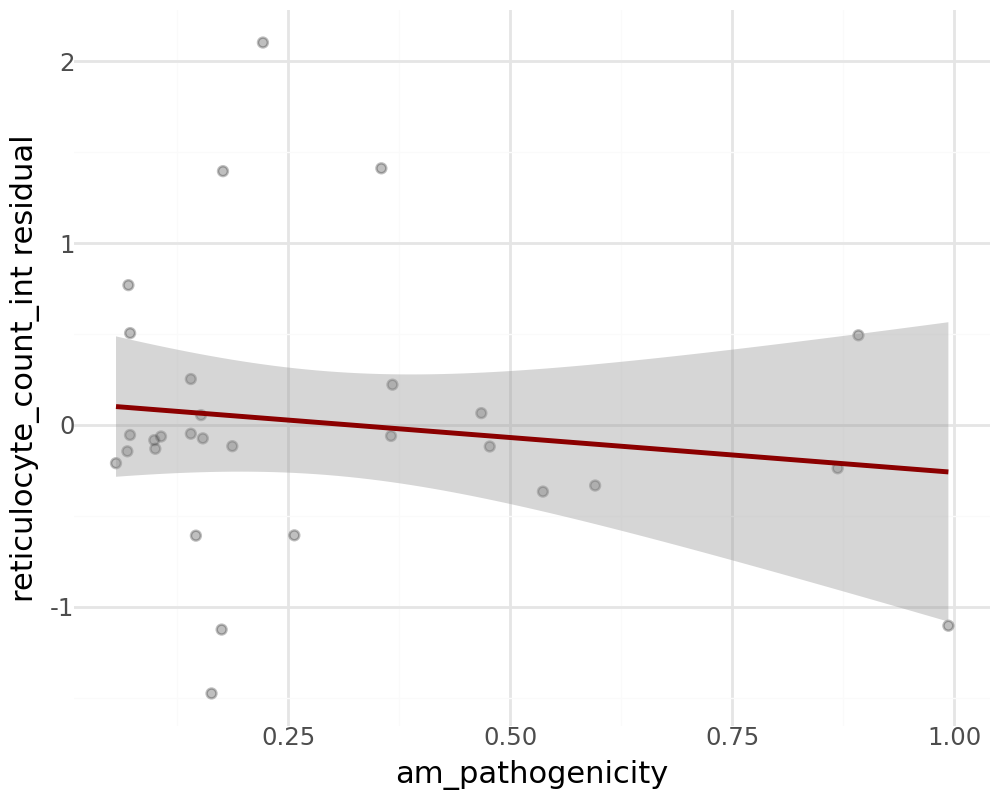

In [22]:
method = 'pearson'
annotation = 'am_pathogenicity'
gene_name = "ANK1"
phenotype = "reticulocyte_count_int"

sc_df = pheno_anno.filter(
    (pl.col('phenotype') == phenotype) &
    (pl.col('gene_name') == gene_name) &
    (pl.col('annotation') == annotation)
)

(
    ggplot(sc_df, aes(x='annotation_score', y='mean_pheno_value')) +
    geom_point(alpha=0.25) +
    geom_smooth(method='lm', se=True, color='darkred') +
    theme_minimal() +
    labs(
        x=f"{annotation}",
        y=f"{phenotype} residual"
    ) +
    theme(figure_size=(5, 4))
)

# Old code

### Anno against anno plot

In [50]:
anno1 = 'am_pathogenicity'
anno2 = 'cadd_raw'
anno1 = 'HXK4_HUMAN_Gersing_2022_activity'
anno2 = 'HXK4_HUMAN_Gersing_2023_abundance'

sc_df = pheno_anno.filter(
    (pl.col('phenotype') == 'glycated_haemoglobin_hba1c_int') &
    (pl.col('annotation').is_in([anno1, anno2]))
    # (pl.col('annotation').str.contains('HXK4'))
).pivot(
    index = ['id', 'mean_pheno_value', 'mean_pheno_value_rank'],
    on='annotation',
    values='annotation_score'
)

(
    ggplot(sc_df, aes(x=anno1, y=anno2)) +
    geom_point(alpha=0.25) +
    geom_smooth(method='lm', se=True, color='darkred') +
    theme_minimal() +
    labs(
        x=anno1, #"DMS activity",
        y=anno2 #"DMS abundance"
    ) +
    annotate(
        "text", 
        x=3.5, y=0.1,
        label=f"Spearman r = {sc_df.select(pl.corr(anno1, anno2, method='spearman')).item():.2f}",
        size=10, color='black'
    ) +
    theme(figure_size=(5, 4))
)

ColumnNotFoundError: unable to find column "HXK4_HUMAN_Gersing_2022_activity"; valid columns: ["id", "mean_pheno_value", "mean_pheno_value_rank"]

### Facet by n_variant bins

In [ ]:
n_cuts = 5
corr_pd['n_var_quantile'] = pd.qcut(corr_pd['n_variants'], n_cuts, labels=[f'{i}' for i in range(1, n_cuts+1)])
corr_pd['n_var_quantile'].value_counts()

n_var_quantile
1    289
4    187
3    170
5    153
2    119
Name: count, dtype: int64

/tmp/ipykernel_1043668/740667702.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


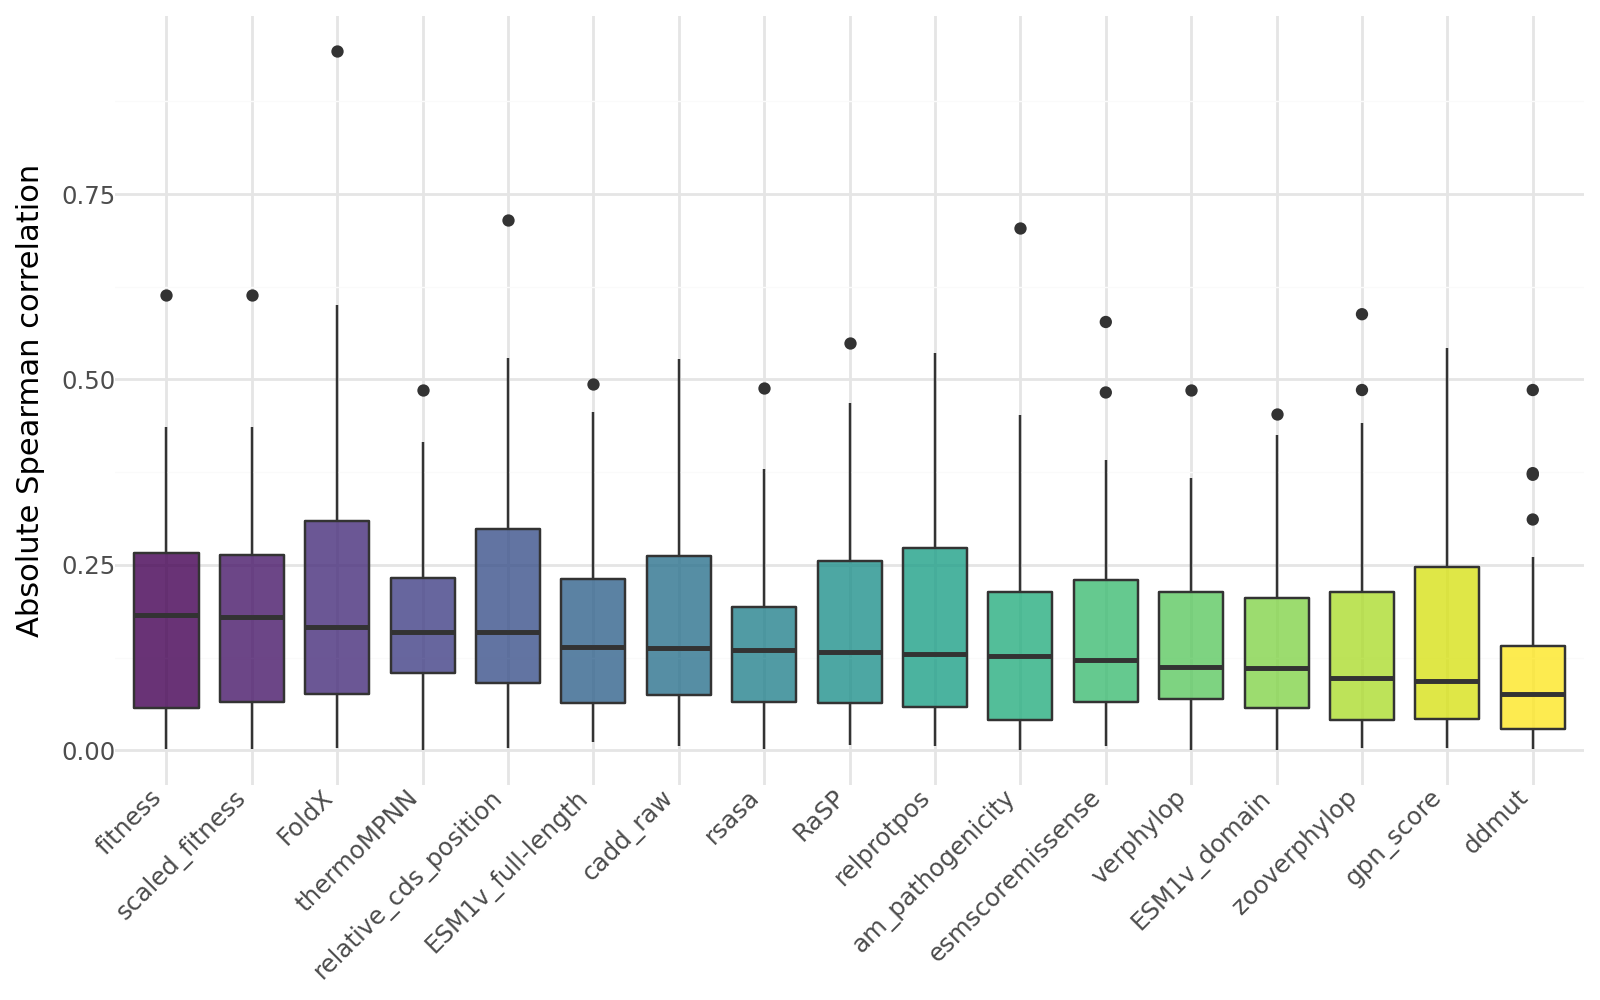

In [ ]:
corr_q1 = corr_pd[corr_pd[f'n_var_quantile']=='1']

med_df = (
    corr_q1
    .groupby("annotation", as_index=False)
    .agg(median_abs_corr_lq=("abs_corr", "median"))
)

corr_q1 = corr_q1.merge(med_df, on='annotation')
order = corr_q1.sort_values("median_abs_corr_lq", ascending=False)["annotation"].unique()

(
    ggplot(corr_pd, aes(x='annotation', y='abs_corr', fill='annotation')) +
    geom_boxplot(alpha=0.8) +
    theme_minimal() +
    # scale_y_sqrt(limits=[0, 0.6], breaks=[b*0.1 for b in range(8)]) +
    scale_fill_manual(values=color_dict) +
    labs(
        x='',
        y='Absolute Spearman correlation'
    ) +
    theme(
        figure_size=(8, 5),
        legend_position='none',
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

## Debugging

In [ ]:
a = pl.read_parquet('/home/dnanexus/data_dir/genebass_continuous_associations_ukbbgym.pq').with_columns(
    (pl.col('description').str.replace_all(r"\(", "").str.replace_all(r"\)", "").str.replace_all(' ', '_').str.to_lowercase() + '_int').alias('phenotype'),
    pl.col('gene_id').alias('region'),
    pl.col('gene_symbol').alias('gene_name')
).filter(
    (pl.col('annotation').str.contains('pLoF')) &
    # (pl.col('annotation') == 'pLoF') &
    (pl.col('phenotype').is_in(appv['phenotype'].unique())) &
    (pl.col('region').is_in(melted_anno['region'].unique()))
)

# Keep the top hit per gene
# a = a.sort("Pvalue").unique(subset=["region"], keep="first")

gene_trait_df = a[['region', 'gene_id', 'gene_name', 'phenotype', 'trait_type']].unique()

# Get beta directions
plof = pl.read_parquet('/home/dnanexus/data_dir/rvat_EUR_500k_regenie.parquet').with_columns(
    (pl.col('trait') + '_int').alias('phenotype'),
    pl.col('gene_id').alias('region')
)

gene_trait_df = gene_trait_df.join(plof[['region', 'phenotype', 'beta']], on=['region', 'phenotype'], how='inner').with_columns(
    (pl.col('beta')/pl.col('beta').abs()).alias('beta_dir')
)

gene_trait_df